# sample4 - 回帰（カスタム学習ループ）

ニューラルネットワークで**数値を予測する回帰**を学びます。  
住宅価格データを使い、カスタム学習ループを丁寧に組み立てます。

| ステップ | 内容 |
|----------|------|
| 1 | データ準備 |
| 2 | モデル定義 |
| 3 | 学習ループ（train / val 分離） |
| 4 | 評価・可視化 |

## 1. データ準備

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X, y = housing.data, housing.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test  = scaler_y.transform(y_test)

# Tensor に変換
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

print("X_train:", X_train.shape, "y_train:", y_train.shape)

X_train: torch.Size([16512, 8]) y_train: torch.Size([16512, 1])


## 2. モデル定義

In [2]:
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # 出力は1次元（価格）
        )

    def forward(self, x):
        return self.net(x)

model = RegressionNet(input_dim=X_train.shape[1])
print(model)

RegressionNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. 学習ループ

訓練と検証を分けて、過学習を監視します。
- `model.train()` → 学習モード（Dropout等が有効）
- `model.eval()`  → 評価モード（Dropout等が無効）

In [3]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 200
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- 学習フェーズ ---
    model.train()
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # --- 検証フェーズ ---
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test)
        val_loss = criterion(val_pred, y_test)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

Epoch [50/200] Train Loss: 0.4362 | Val Loss: 0.4446
Epoch [100/200] Train Loss: 0.3329 | Val Loss: 0.3498
Epoch [150/200] Train Loss: 0.2981 | Val Loss: 0.3125
Epoch [200/200] Train Loss: 0.2763 | Val Loss: 0.2877


## 4. 評価・可視化

/tmp/ipykernel_49936/176807196.py:9: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/176807196.py:9: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/176807196.py:9: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/176807196.py:9: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/402_PyTorch/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/HOME/sample/sample_python/402_PyTorch/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32722 (\N{CJK UNIFI

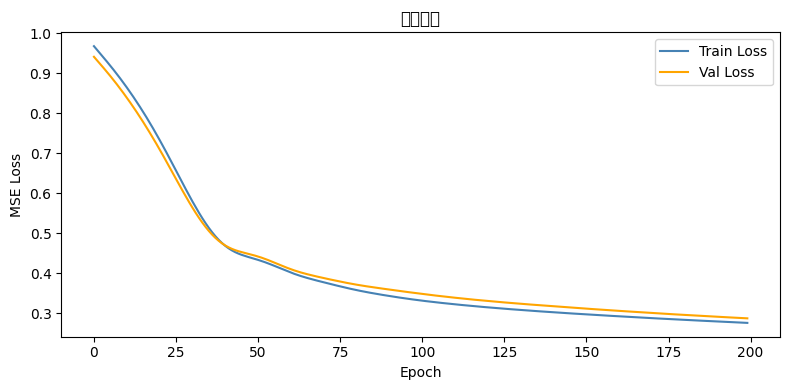

In [4]:
# Loss の推移
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='orange')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("学習曲線")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_49936/411062250.py:17: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/411062250.py:17: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/411062250.py:17: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/411062250.py:17: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49936/411062250.py:17: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/402_PyTorch/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

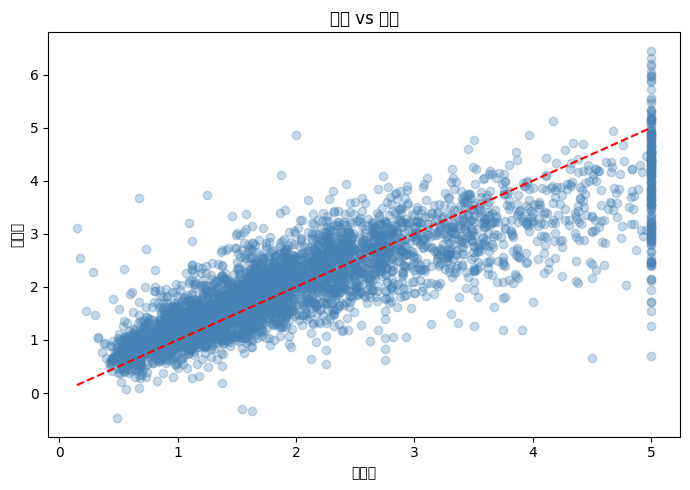

In [5]:
# 正解 vs 予測
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()
    y_true = y_test.numpy()

# スケールを元に戻す
y_pred = scaler_y.inverse_transform(y_pred)
y_true = scaler_y.inverse_transform(y_true)

plt.figure(figsize=(7, 5))
plt.scatter(y_true, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("正解値")
plt.ylabel("予測値")
plt.title("正解 vs 予測")
plt.tight_layout()
plt.show()